In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Veri setini indirme
!kaggle datasets download -d paultimothymooney/breast-histopathology-images

# Sıkıştırılmış dosyayı data klasörüne çıkartma
!unzip -q breast-histopathology-images.zip -d data/

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/breast-histopathology-images
License(s): CC0-1.0
100% 3.09G/3.10G [01:11<00:00, 137MB/s]
100% 3.10G/3.10G [01:11<00:00, 46.6MB/s]


In [ ]:
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

# 1. Görüntü Yollarını ve Etiketlerini Toplama
# glob ile data klasörü altındaki tüm .png dosyalarını buluyoruz
image_paths = glob.glob('/content/data/**/*.png', recursive=True)

# Etiketleri (0: Negatif, 1: Pozitif) görüntünün bulunduğu üst klasörün adından çekiyoruz
labels = [int(os.path.basename(os.path.dirname(path))) for path in image_paths if os.path.basename(os.path.dirname(path)) in ['0', '1']]
image_paths = [path for path in image_paths if os.path.basename(os.path.dirname(path)) in ['0', '1']]

df = pd.DataFrame({'image_path': image_paths, 'label': labels})
print(f"Orijinal Veri Seti Boyutu: {len(df)}")

# ÖNEMLİ: Hızlı deneme için veri setinden rastgele 10.000 örnek alıyoruz.
# Tam eğitim yapacağınız zaman aşağıdaki satırı yoruma alınız (# koyunuz).
df = df.sample(10000, random_state=42).reset_index(drop=True)

# 2. Veriyi Eğitim (%70), Doğrulama (%15) ve Test (%15) Olarak Bölme
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])

print(f"Kullanılan Veri - Eğitim: {len(train_df)} | Doğrulama: {len(val_df)} | Test: {len(test_df)}")

# 3. PyTorch Dataset Sınıfı ve Transformasyonlar
class IDCDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label']
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

transform = transforms.Compose([
    transforms.Resize((50, 50)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

batch_size = 64
train_loader = DataLoader(IDCDataset(train_df, transform), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(IDCDataset(val_df, transform), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(IDCDataset(test_df, transform), batch_size=batch_size, shuffle=False)

print("DataLoader nesneleri GPU/CPU beslemesi için hazır!")

Orijinal Veri Seti Boyutu: 555048
Kullanılan Veri - Eğitim: 7000 | Doğrulama: 1500 | Test: 1500
DataLoader nesneleri GPU/CPU beslemesi için hazır!


In [ ]:
# --- 1. ÖZEL CNN (CUSTOM CNN) MİMARİSİ ---
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.fc1 = nn.Linear(128 * 6 * 6, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 2) # İki sınıf: 0 ve 1
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1) # Düzleştirme (Flatten)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

custom_model = CustomCNN()

# --- 2. VGG-16 TRANSFER LEARNING MİMARİSİ ---
# Pretrained (Önceden eğitilmiş) ağırlıkları indiriyoruz
vgg16_model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# Özellik çıkarıcı (Feature Extractor) katmanları donduruyoruz ki önceki öğrendikleri bozulmasın
for param in vgg16_model.parameters():
    param.requires_grad = False

# Sınıflandırıcı kısmının son katmanını kendi 2 sınıfımız (kanserli/değil) için değiştiriyoruz
num_features = vgg16_model.classifier[6].in_features
vgg16_model.classifier[6] = nn.Linear(num_features, 2)

print("Özel CNN ve VGG-16 Modelleri başarıyla tanımlandı!")

Özel CNN ve VGG-16 Modelleri başarıyla tanımlandı!


In [ ]:
import time
import torch.optim as optim

# GPU'nun (CUDA) aktif olup olmadığını kontrol ediyoruz
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Eğitim için kullanılacak cihaz: {device}")

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    # Modeli GPU'ya gönderiyoruz
    model = model.to(device)

    # Raporlama ve grafik çizimi için metrikleri saklayacağımız sözlük
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        start_time = time.time()

        # --- EĞİTİM (TRAINING) AŞAMASI ---
        model.train() # Modeli eğitim moduna alıyoruz (Dropout vb. aktif olur)
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Gradyanları sıfırlama
            optimizer.zero_grad()

            # İleri yayılım (Forward pass) ve kayıp hesaplama
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Geri yayılım (Backward pass) ve ağırlıkların güncellenmesi
            loss.backward()
            optimizer.step()

            # İstatistikleri toplama
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct_train / total_train

        # --- DOĞRULAMA (VALIDATION) AŞAMASI ---
        model.eval() # Modeli değerlendirme moduna alıyoruz (Dropout pasif olur)
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        # Doğrulama sırasında bellek ve hız tasarrufu için gradyan hesaplamayı kapatıyoruz
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = correct_val / total_val

        # Sonuçları history sözlüğüne kaydetme
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        end_time = time.time()
        mins, secs = divmod(end_time - start_time, 60)

        print(f"Epoch {epoch+1}/{num_epochs} | Süre: {int(mins)}dk {int(secs)}sn")
        print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
        print(f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")
        print("-" * 50)

    return model, history

Eğitim için kullanılacak cihaz: cuda


In [ ]:
# Sınıflandırma problemi için uygun kayıp fonksiyonunu tanımlıyoruz
criterion = nn.CrossEntropyLoss()

# --- 1. ÖZEL CNN MODELİNİN EĞİTİLMESİ ---
print("=== ÖZEL CNN MODELİ EĞİTİMİ BAŞLIYOR ===")
# Öğrenme oranını (learning rate) standart bir değer olan 0.001 seçiyoruz
optimizer_custom = optim.Adam(custom_model.parameters(), lr=0.001)

trained_custom, hist_custom = train_model(
    custom_model, train_loader, val_loader, criterion, optimizer_custom, num_epochs=5
)

# --- 2. VGG-16 TRANSFER LEARNING MODELİNİN EĞİTİLMESİ ---
print("\n=== VGG-16 TRANSFER LEARNING EĞİTİMİ BAŞLIYOR ===")
# VGG-16'da sadece son katmanı (classifier[6]) değiştirdiğimiz için sadece o kısmın parametrelerini optimize ediyoruz.
# Transfer öğrenmede ağırlıkların çok sarsılmaması için öğrenme oranını daha düşük (0.0001) tutmak iyi bir pratiktir.
optimizer_vgg16 = optim.Adam(vgg16_model.classifier[6].parameters(), lr=0.0001)

trained_vgg16, hist_vgg16 = train_model(
    vgg16_model, train_loader, val_loader, criterion, optimizer_vgg16, num_epochs=5
)

=== ÖZEL CNN MODELİ EĞİTİMİ BAŞLIYOR ===
Epoch 1/5 | Süre: 0dk 14sn
Train Loss: 0.4510 | Train Acc: 0.7989
Val Loss: 0.3815 | Val Acc: 0.8393
--------------------------------------------------
Epoch 2/5 | Süre: 0dk 7sn
Train Loss: 0.3997 | Train Acc: 0.8270
Val Loss: 0.3791 | Val Acc: 0.8347
--------------------------------------------------
Epoch 3/5 | Süre: 0dk 8sn
Train Loss: 0.3851 | Train Acc: 0.8326
Val Loss: 0.3845 | Val Acc: 0.8360
--------------------------------------------------
Epoch 4/5 | Süre: 0dk 7sn
Train Loss: 0.3757 | Train Acc: 0.8424
Val Loss: 0.3789 | Val Acc: 0.8473
--------------------------------------------------
Epoch 5/5 | Süre: 0dk 7sn
Train Loss: 0.3754 | Train Acc: 0.8423
Val Loss: 0.3612 | Val Acc: 0.8480
--------------------------------------------------

=== VGG-16 TRANSFER LEARNING EĞİTİMİ BAŞLIYOR ===
Epoch 1/5 | Süre: 0dk 10sn
Train Loss: 0.5222 | Train Acc: 0.7560
Val Loss: 0.4027 | Val Acc: 0.8240
--------------------------------------------------


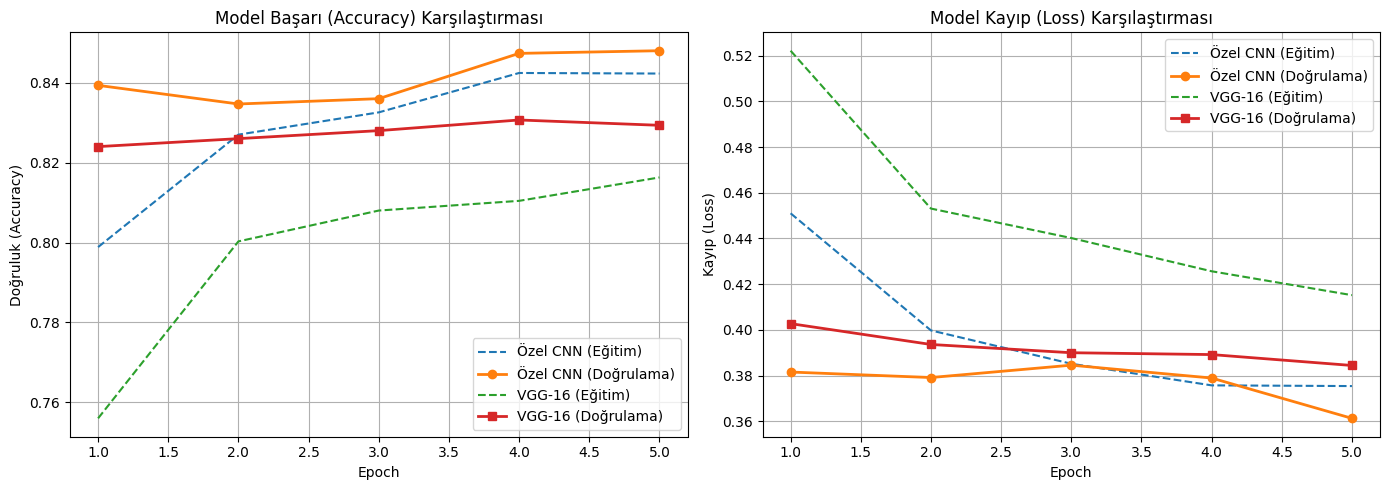

In [ ]:
import matplotlib.pyplot as plt

# Epoch sayımız
epochs = range(1, 6)

plt.figure(figsize=(14, 5))

# 1. Doğruluk (Accuracy) Grafiği
plt.subplot(1, 2, 1)
plt.plot(epochs, hist_custom['train_acc'], label='Özel CNN (Eğitim)', linestyle='--')
plt.plot(epochs, hist_custom['val_acc'], label='Özel CNN (Doğrulama)', marker='o', linewidth=2)
plt.plot(epochs, hist_vgg16['train_acc'], label='VGG-16 (Eğitim)', linestyle='--')
plt.plot(epochs, hist_vgg16['val_acc'], label='VGG-16 (Doğrulama)', marker='s', linewidth=2)
plt.title('Model Başarı (Accuracy) Karşılaştırması')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk (Accuracy)')
plt.legend()
plt.grid(True)

# 2. Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs, hist_custom['train_loss'], label='Özel CNN (Eğitim)', linestyle='--')
plt.plot(epochs, hist_custom['val_loss'], label='Özel CNN (Doğrulama)', marker='o', linewidth=2)
plt.plot(epochs, hist_vgg16['train_loss'], label='VGG-16 (Eğitim)', linestyle='--')
plt.plot(epochs, hist_vgg16['val_loss'], label='VGG-16 (Doğrulama)', marker='s', linewidth=2)
plt.title('Model Kayıp (Loss) Karşılaştırması')
plt.xlabel('Epoch')
plt.ylabel('Kayıp (Loss)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# 1. VGG-16'yı önceden eğitilmiş ağırlıklarıyla tekrar yüklüyoruz
vgg16_finetune = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# 2. FINE-TUNING STRATEJİSİ:
# VGG-16'nın 'features' kısmı 31 katmandan oluşur. Son evrişim bloğu (Block 5) 24. indeksten başlar.
# İlk 4 bloğu donduruyoruz (ImageNet'in temel şekil, kenar bilgilerini koruyoruz)
for param in vgg16_finetune.features[:24].parameters():
    param.requires_grad = False

# 5. Bloğun kilidini açıyoruz (Medikal hücre dokularını öğrenmesi için)
for param in vgg16_finetune.features[24:].parameters():
    param.requires_grad = True

# 3. Sınıflandırıcıyı kendi 2 sınıfımız (IDC+ / IDC-) için değiştiriyoruz
num_features = vgg16_finetune.classifier[6].in_features
vgg16_finetune.classifier[6] = nn.Linear(num_features, 2)

# 4. Optimizasyon: İki farklı öğrenme oranı (Differential Learning Rate) kullanıyoruz
# İnce ayar yapılan evrişim katmanları için ÇOK DÜŞÜK (1e-5), yeni sınıflandırıcı için düşük (1e-4)
optimizer_ft = optim.Adam([
    {'params': vgg16_finetune.features[24:].parameters(), 'lr': 1e-5},
    {'params': vgg16_finetune.classifier[6].parameters(), 'lr': 1e-4}
])

criterion = nn.CrossEntropyLoss()

print("=== VGG-16 FINE-TUNING (İNCE AYAR) EĞİTİMİ BAŞLIYOR ===")
trained_vgg_ft, hist_vgg_ft = train_model(
    vgg16_finetune, train_loader, val_loader, criterion, optimizer_ft, num_epochs=5
)

=== VGG-16 FINE-TUNING (İNCE AYAR) EĞİTİMİ BAŞLIYOR ===
Epoch 1/5 | Süre: 0dk 11sn
Train Loss: 0.4916 | Train Acc: 0.7684
Val Loss: 0.3747 | Val Acc: 0.8327
--------------------------------------------------
Epoch 2/5 | Süre: 0dk 11sn
Train Loss: 0.3971 | Train Acc: 0.8231
Val Loss: 0.3615 | Val Acc: 0.8380
--------------------------------------------------
Epoch 3/5 | Süre: 0dk 11sn
Train Loss: 0.3656 | Train Acc: 0.8383
Val Loss: 0.3526 | Val Acc: 0.8433
--------------------------------------------------
Epoch 4/5 | Süre: 0dk 11sn
Train Loss: 0.3448 | Train Acc: 0.8461
Val Loss: 0.3440 | Val Acc: 0.8500
--------------------------------------------------
Epoch 5/5 | Süre: 0dk 11sn
Train Loss: 0.3241 | Train Acc: 0.8591
Val Loss: 0.3424 | Val Acc: 0.8480
--------------------------------------------------


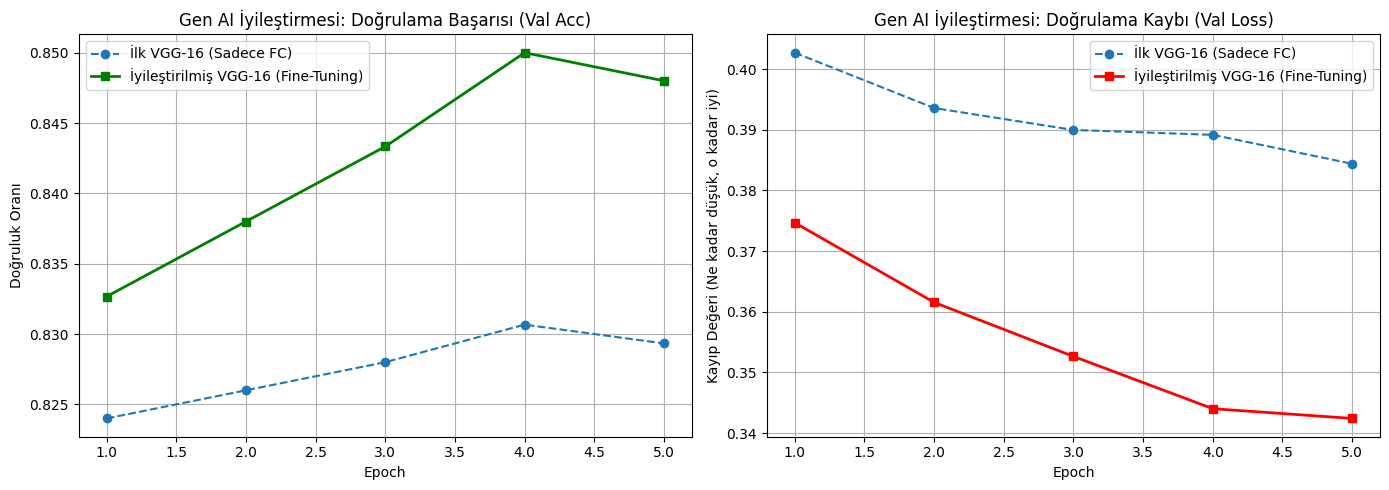

In [ ]:
import matplotlib.pyplot as plt

# Epoch sayımız 5 olduğu için x eksenini 1'den 5'e kadar ayarlıyoruz
epochs = range(1, 6)

plt.figure(figsize=(14, 5))

# --- 1. Doğruluk (Accuracy) Grafiği ---
plt.subplot(1, 2, 1)
plt.plot(epochs, hist_vgg16['val_acc'], label='İlk VGG-16 (Sadece FC)', marker='o', linestyle='--')
plt.plot(epochs, hist_vgg_ft['val_acc'], label='İyileştirilmiş VGG-16 (Fine-Tuning)', marker='s', linewidth=2, color='green')
plt.title('Gen AI İyileştirmesi: Doğrulama Başarısı (Val Acc)')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk Oranı')
plt.legend()
plt.grid(True)

# --- 2. Kayıp (Loss) Grafiği ---
plt.subplot(1, 2, 2)
plt.plot(epochs, hist_vgg16['val_loss'], label='İlk VGG-16 (Sadece FC)', marker='o', linestyle='--')
plt.plot(epochs, hist_vgg_ft['val_loss'], label='İyileştirilmiş VGG-16 (Fine-Tuning)', marker='s', linewidth=2, color='red')
plt.title('Gen AI İyileştirmesi: Doğrulama Kaybı (Val Loss)')
plt.xlabel('Epoch')
plt.ylabel('Kayıp Değeri (Ne kadar düşük, o kadar iyi)')
plt.legend()
plt.grid(True)

# Grafikleri ekrana düzgünce sığdırma ve gösterme
plt.tight_layout()
plt.show()

1) ÖZEL CNN MODELİ: KATMAN ÖZELLİKLERİ VE PARAMETRELERİ
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 50, 50]             896
              ReLU-2           [-1, 32, 50, 50]               0
         MaxPool2d-3           [-1, 32, 25, 25]               0
            Conv2d-4           [-1, 64, 25, 25]          18,496
              ReLU-5           [-1, 64, 25, 25]               0
         MaxPool2d-6           [-1, 64, 12, 12]               0
            Conv2d-7          [-1, 128, 12, 12]          73,856
              ReLU-8          [-1, 128, 12, 12]               0
         MaxPool2d-9            [-1, 128, 6, 6]               0
           Linear-10                  [-1, 512]       2,359,808
             ReLU-11                  [-1, 512]               0
          Dropout-12                  [-1, 512]               0
           Linear-13                    [-1, 2]

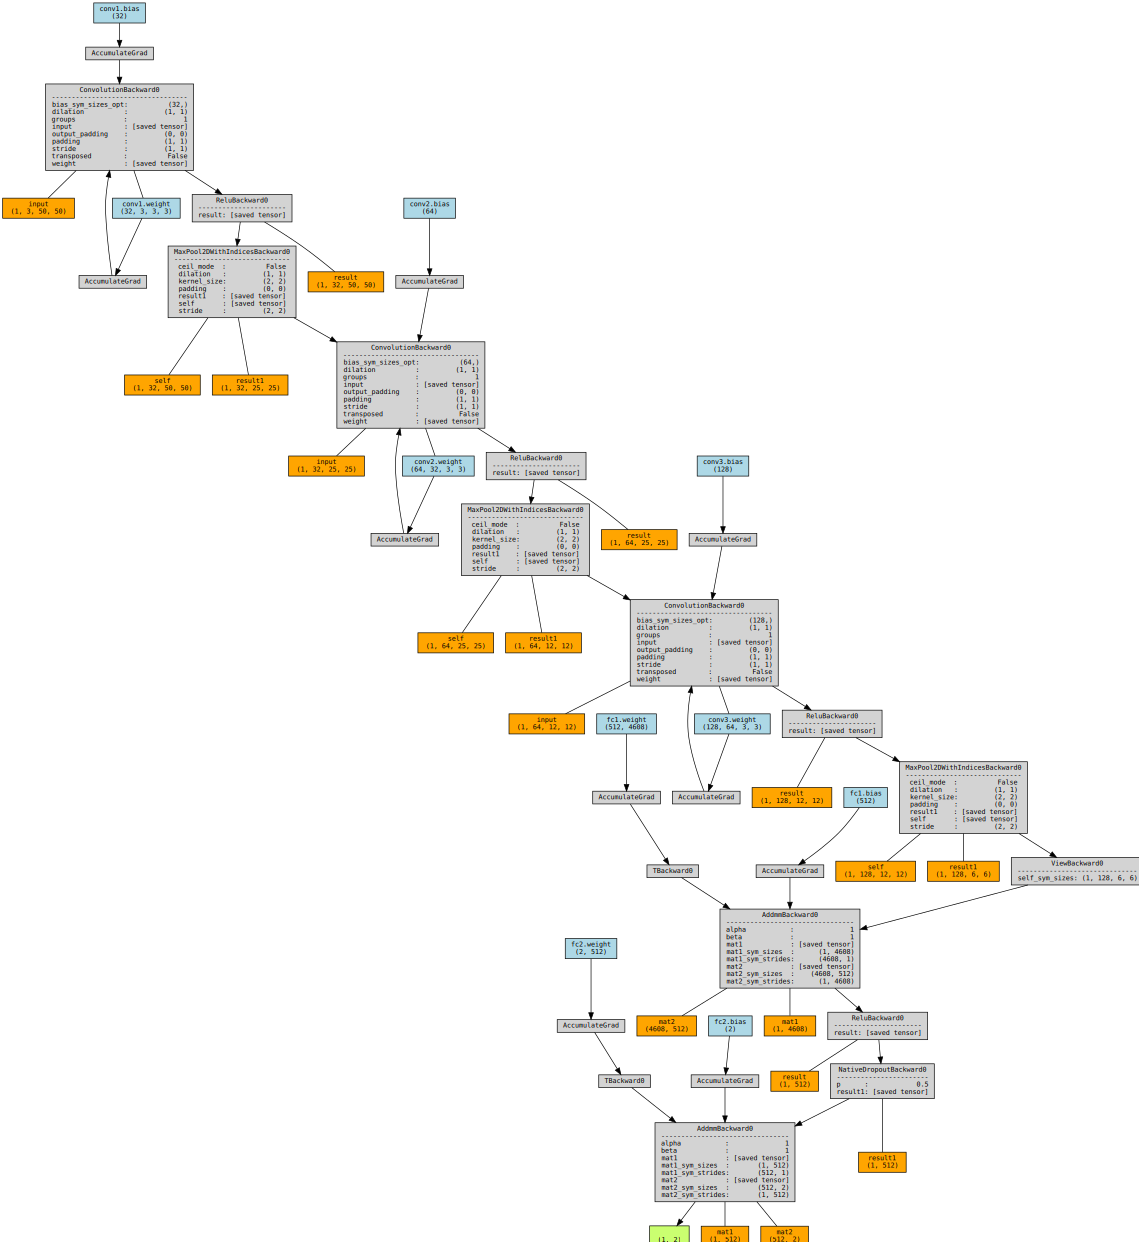



2) VGG-16 (TRANSFER LEARNING): KATMAN ÖZELLİKLERİ VE PARAMETRELERİ
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 50, 50]           1,792
              ReLU-2           [-1, 64, 50, 50]               0
            Conv2d-3           [-1, 64, 50, 50]          36,928
              ReLU-4           [-1, 64, 50, 50]               0
         MaxPool2d-5           [-1, 64, 25, 25]               0
            Conv2d-6          [-1, 128, 25, 25]          73,856
              ReLU-7          [-1, 128, 25, 25]               0
            Conv2d-8          [-1, 128, 25, 25]         147,584
              ReLU-9          [-1, 128, 25, 25]               0
        MaxPool2d-10          [-1, 128, 12, 12]               0
           Conv2d-11          [-1, 256, 12, 12]         295,168
             ReLU-12          [-1, 256, 12, 12]               0
           Conv2d-13          [-1,

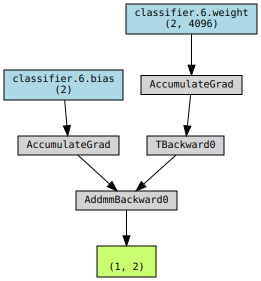

In [ ]:
# Gerekli kütüphaneleri kuruyoruz
%pip install torchviz
%pip install torchsummary

import torch
import torch.nn as nn # Added import for nn
import torchvision.models as models # Added import for models
from torchsummary import summary
from torchviz import make_dot

# --- 1. ÖZEL CNN (CUSTOM CNN) MİMARİSİ ---
# Redefining CustomCNN and custom_model as they were not found in the environment.
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.fc1 = nn.Linear(128 * 6 * 6, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 2) # İki sınıf: 0 ve 1
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1) # Düzleştirme (Flatten)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

custom_model = CustomCNN()

# --- 2. VGG-16 TRANSFER LEARNING MİMARİSİ ---
# Redefining vgg16_model as it was not found in the environment.
vgg16_model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

for param in vgg16_model.parameters():
    param.requires_grad = False

num_features = vgg16_model.classifier[6].in_features
vgg16_model.classifier[6] = nn.Linear(num_features, 2)

# Modelin nerede çalıştığını otomatik buluyoruz (GPU veya CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Modelleri GPU'ya taşıyoruz
custom_model.to(device)
vgg16_model.to(device)

print("======================================================")
print("1) ÖZEL CNN MODELİ: KATMAN ÖZELLİKLERİ VE PARAMETRELERİ")
print("======================================================")
summary(custom_model, input_size=(3, 50, 50))

# Özel CNN'in Şeklini Çizdirme
# DÜZELTME: x_custom tensörünü model ile aynı cihaza (.to(device)) gönderiyoruz
x_custom = torch.randn(1, 3, 50, 50).to(device)
y_custom = custom_model(x_custom)
dot_custom = make_dot(y_custom, params=dict(custom_model.named_parameters()), show_attrs=True, show_saved=True)
dot_custom.format = 'png'
dot_custom.render("ozel_cnn_mimarisi")
print("\nÖzel CNN Modelinin şekli 'ozel_cnn_mimarisi.png' olarak kaydedildi ve aşağıda çizdirildi:")
display(dot_custom)


print("\n\n======================================================")
print("2) VGG-16 (TRANSFER LEARNING): KATMAN ÖZELLİKLERİ VE PARAMETRELERİ")
print("======================================================")
summary(vgg16_model, input_size=(3, 50, 50))

# VGG-16'nın Şeklini Çizdirme
# DÜZELTME: x_vgg tensörünü model ile aynı cihaza (.to(device)) gönderiyoruz
x_vgg = torch.randn(1, 3, 50, 50).to(device)
y_vgg = vgg16_model(x_vgg)
dot_vgg = make_dot(y_vgg, params=dict(vgg16_model.named_parameters()))
dot_vgg.format = 'png'
dot_vgg.render("vgg16_mimarisi")
print("\nVGG-16 Modelinin şekli 'vgg16_mimarisi.png' olarak kaydedildi ve aşağıda çizdirildi:")
display(dot_vgg)
